In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()

video_path = list(uploaded.keys())[0]
print("Video loaded:", video_path)

Saving 4754906-uhd_3840_2160_30fps.mp4 to 4754906-uhd_3840_2160_30fps.mp4
Video loaded: 4754906-uhd_3840_2160_30fps.mp4


In [4]:
cap = cv2.VideoCapture(video_path)

frames = []

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frames.append(frame)

cap.release()

print("Total Frames:", len(frames))

frame1 = frames[31]
frame2 = frames[36]

frame1_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY).astype(np.float32)
frame2_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY).astype(np.float32)

Total Frames: 359


In [5]:
def horn_schunck(img1, img2, alpha=1.0, iterations=200):

    kernel_x = np.array([[-1, 1],
                         [-1, 1]]) * 0.25

    kernel_y = np.array([[-1, -1],
                         [ 1,  1]]) * 0.25

    kernel_t = np.ones((2,2)) * 0.25

    Ix = cv2.filter2D(img1, -1, kernel_x) + cv2.filter2D(img2, -1, kernel_x)

    Iy = cv2.filter2D(img1, -1, kernel_y) + cv2.filter2D(img2, -1, kernel_y)

    It = cv2.filter2D(img2, -1, kernel_t) - cv2.filter2D(img1, -1, kernel_t)

    u = np.zeros(img1.shape)
    v = np.zeros(img1.shape)

    avg_kernel = np.array([[1/12, 1/6, 1/12],
                           [1/6,  0,  1/6],
                           [1/12, 1/6, 1/12]])

    for _ in range(iterations):

        u_avg = cv2.filter2D(u, -1, avg_kernel)
        v_avg = cv2.filter2D(v, -1, avg_kernel)

        numerator = Ix*u_avg + Iy*v_avg + It
        denominator = alpha**2 + Ix**2 + Iy**2

        u = u_avg - Ix*(numerator/denominator)
        v = v_avg - Iy*(numerator/denominator)

    return u, v

In [6]:
u, v = horn_schunck(
    frame1_gray,
    frame2_gray,
    alpha=1.0,
    iterations=300
)

print("Optical Flow Computed")

Optical Flow Computed


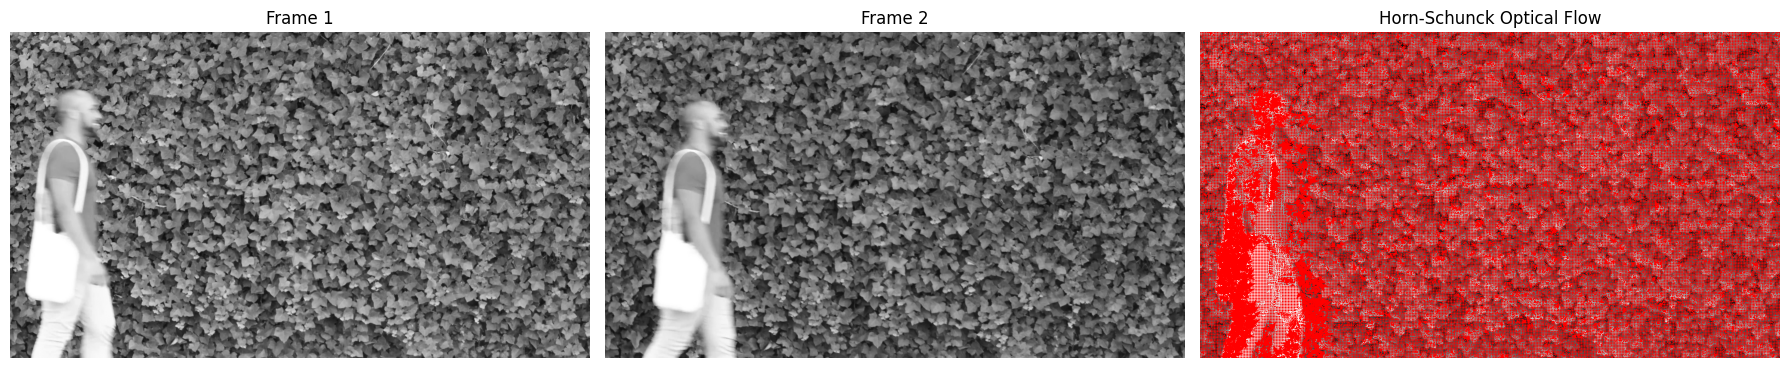

In [7]:
step = 10

y, x = np.mgrid[
    step/2:frame1_gray.shape[0]:step,
    step/2:frame1_gray.shape[1]:step
].astype(int)

u_sample = u[y, x]
v_sample = v[y, x]

plt.figure(figsize=(18,5))

# Frame 1
plt.subplot(1,3,1)
plt.imshow(frame1_gray, cmap='gray')
plt.title("Frame 1")
plt.axis('off')

# Frame 2
plt.subplot(1,3,2)
plt.imshow(frame2_gray, cmap='gray')
plt.title("Frame 2")
plt.axis('off')

# Optical Flow
plt.subplot(1,3,3)
plt.imshow(frame1_gray, cmap='gray')
plt.quiver(
    x,
    y,
    u_sample,
    v_sample,
    color='red'
)
plt.title("Horn-Schunck Optical Flow")
plt.axis('off')

plt.tight_layout()
plt.show()